In [ ]:
import os
import getpass
from langchain_chroma import Chroma
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain.tools import tool
from langchain.chat_models import init_chat_model
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage, ToolMessage
from typing import TypedDict, Optional, List
from typing_extensions import NotRequired
from langchain_core.documents import Document
from langgraph.graph import MessagesState, StateGraph, START, END
import operator
from typing import Annotated
from typing import List, Literal, Optional
from pydantic import BaseModel, Field
from langgraph.types import interrupt, Command, RetryPolicy
from typing import cast
from langgraph.types import Command
from langgraph.graph import END
from langchain_core.messages import HumanMessage, AIMessage, AnyMessage
from langchain.tools import tool, ToolRuntime
from prompts_old import QUERY_ANALYZER_PROMPT, GENERATOR_SYSTEM_PROMPT, REVIEWER_SYSTEM_PROMPT, REWRITE_PROMPT


if not os.environ.get("GOOGLE_API_KEY"):
    os.environ["GOOGLE_API_KEY"] = getpass.getpass("Enter API key for Google Gemini: ")

model = init_chat_model(
    "google_genai:gemini-2.5-flash",
    temperature=0
)
embeddings = GoogleGenerativeAIEmbeddings(model="models/gemini-embedding-001")

# Vector store
vector_store = Chroma(
    # collection_name="whitepapers",
    collection_name="whitepapers",
    embedding_function=embeddings,
    persist_directory="./chroma_langchain_db",
)

In [2]:
def format_chat_history(messages) -> str:
    """
    Produce a human-readable transcript like:
    User: ...
    Assistant: ...
    Tool: ...
    """

    lines = []
    for msg in messages:
        if isinstance(msg, HumanMessage):
            lines.append(f"User: {msg.content}")
        elif isinstance(msg, AIMessage):
            lines.append(f"Assistant: {msg.content}")
        elif isinstance(msg, SystemMessage):
            lines.append(f"System: {msg.content}")
        elif isinstance(msg, ToolMessage):
            tool_name = msg.additional_kwargs.get("tool_name", "tool")
            lines.append(f"Tool[{tool_name}]: {msg.content}")
        else:
            # fallback for unknown message types
            role = getattr(msg, "role", "unknown")
            lines.append(f"{role.capitalize()}: {msg.content}")
    return "\n".join(lines)


@tool
def rag_context_retriever(query, k=5) -> str:
    """Retrieve relevant documents from the vector store based on the query.
    Args:
        query (str): The input query string.
        k (int): The number of top similar documents to retrieve.
    Returns:
        Formatted Context.
    """
    # vector_store.similarity_search_with_relevance_scores(query, k=k)
    context_with_metadata = vector_store.similarity_search(query, k=k)
    contexts = [doc.page_content for doc in context_with_metadata]
    formatted_contexts = "\n---\n".join(contexts)
    print(f"Retrieved {len(contexts)} contexts for the query: '{query}'")
    return formatted_contexts


# Augment the LLM with tools
tools = [rag_context_retriever]
tools_by_name = {tool.name: tool for tool in tools}
model_with_tools = model.bind_tools(tools)
model_with_tools.invoke("Use the tool to gather context and answer based on it.\nUSER QUERY: What is observability")

AIMessage(content='', additional_kwargs={'function_call': {'name': 'rag_context_retriever', 'arguments': '{"query": "What is observability"}'}, '__gemini_function_call_thought_signatures__': {'ae7c7f4c-5c68-4167-9a74-151ee53461ff': 'CoUDAXLI2nzmqolCDCcEOCJPPyuZfsrFwchSvOMmSh6oLGnjxu0Y39spZlOwTyVk9hmMTUFMWvA2pB5cmgwDN1KV0JlPv8f8UJpQv3+xTDntxPhQBydT+5R06nuTRjKIat4kZkiXn4VGxDKhJYljKFv+Oe9x9PESI6x8TTaIREVSJkwaWP1yvnuby4AyOOH4dhCs+n1a/3bqd0aGQY7BfVh/ih7Cc+I2uotK8YuEaKxhQCspZFuimTOlcyGybKsF2ddc2lLAyHZUAA5hjsxxDqTAz2eZtqPt6uryjY/LQu9WzZsHuj7w5Pil3eqD0fJrTl8jU6UTphB7OdW+Lx2b9Ec2YhZyAu2o6kOwsbFpfvvwK2R3g0zgdpJIyjOOqJ6OfJFVQ0HEXZ2LEZ1TJiylW9Mhj5uUMKcEqlyKfEBv6TlmCTxYSKadyZliy6GD0yrsc+ie0jTvpM/8mlRe919VhgPsPJZerkbdelJ/88NSl2AC1Z5J8Zx9PZTreNWyFOYI4pW6tzIzXXo='}}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019b2e7d-0306-73f1-bd7f-04ec3

# State & Structured Output Definition

In [3]:
### Overall State Definition
class AgentState(MessagesState):
    # Core query info
    user_query: str                         # original user input
    rewritten_query: NotRequired[str]       # from QueryAnalyzer, if available

    # # Conversation / agent messages (optional but recommended for agents)
    rag_messages: NotRequired[
        Annotated[List[AnyMessage], operator.add]
    ]

    # Retrieval-related
    retrieved_contexts: NotRequired[Annotated[List[str], operator.add]]  # raw retrieved docs or chunks
    
    # Clarification control
    clarification_counter: int = 0          # to cap number of clarification turns
    clarification_counter_limit: int = 3
    query_analyzer_reasoning: NotRequired[str]
    query_analyzer_intent: NotRequired[str]
    query_analyzer_confidence: NotRequired[float]

    # Final answer from the agent
    final_response: NotRequired[str]

    # Evaluation / QA
    is_good_answer: NotRequired[str]
    reviewer_reason: NotRequired[str]

# Structured Output Definitions for Query Analysis
class QueryAnalysis(BaseModel):
    """Structured output for the Query Analyzer node."""
    # Optional rewritten / normalized query
    rewritten_query: Optional[str] = Field(
        default=None,
        description="A clarified, normalized version of the user query. Only provided when safe to rewrite.",
    )

    # Clarification decision
    needs_clarification: bool = Field(
        ...,
        description="Whether the system must ask a clarification question before proceeding.",
    )

    # Optional clarification questions
    clarification_questions: Optional[List[str]] = Field(
        default=None,
        description="Clarification questions to ask the user if needs_clarification is True.",
    )

    # Optional reasoning fields
    rationale: Optional[str] = Field(
        default=None,
        description="Explanation for reasoning, rewrite choice, and clarification decision.",
    )

    intent: Literal[
        "information_retrieval",
        "greetings_or_generic",
    ] = Field(
        default="greetings_or_generic",
        description="High-level intent classification of the query.",
    )

    confidence: float = Field(
        default=0.0,
        ge=0.0,
        le=1.0,
        description="Model's confidence (0–1) in its analysis.",
    )
model_with_query_analysis = model.with_structured_output(QueryAnalysis)
# model_with_query_analysis.invoke("Analyze the following user query and provide structured output according to the QueryAnalysis schema.\nUSER QUERY: What is observability")

# Structured Output Definitions for Answer Evaluation
class AnswerAnalysis(BaseModel):
    """Structured output for the Answer node."""
    
    # Evaluation / QA
    is_good_answer: str = Field(
        ...,
        description="Indicates whether the answer is satisfactory ('yes' or 'no')."
    )
    
    reviewer_reason: str = Field(
        ...,
        description="Reasoning behind the evaluation of the answer."
    )
model_with_answer_evaluation = model.with_structured_output(AnswerAnalysis)
# model_with_answer_evaluation.invoke("Evaluate the following answer based on its quality and relevance to the user's query.\nUSER QUERY: What is observability?\nAGENT ANSWER: Observability is a measure of how well the internal states of a system can be inferred from its external outputs. It involves collecting, analyzing, and visualizing data from various sources to gain insights into system performance, reliability, and user experience.")


In [4]:
# analysis = model_with_query_analysis.invoke(
#     QUERY_ANALYZER_PROMPT.format(chat_history="", user_query="What is observability?")
# )
# analysis.model_dump()

# Define Nodes

In [12]:
def query_analyzer_node(state: AgentState) -> Command[AgentState]:
    """Node to analyze and potentially rewrite user queries."""

    # Ensure messages key exists
    messages: list[AnyMessage] = state.get("messages", [])
    chat_history = "\n".join(m.pretty_repr() for m in messages)
    # Append the latest user query as a HumanMessage
    messages.append(HumanMessage(content=state["user_query"]))

    # Call LLM with structured output
    analysis: QueryAnalysis = model_with_query_analysis.invoke(
        QUERY_ANALYZER_PROMPT.format(
            chat_history=chat_history,
            user_query=state["user_query"],
        )
    )

    # Default next node
    goto = "generator_node"

    # Persist analysis metadata into state (if present)
    if analysis.rationale is not None:
        state["query_analyzer_reasoning"] = analysis.rationale

    if analysis.intent is not None:
        state["query_analyzer_intent"] = analysis.intent

    if analysis.confidence is not None:
        state["query_analyzer_confidence"] = analysis.confidence

    # Clarification logic
    confidence = analysis.confidence or 0.0
    clarification_counter = state.get("clarification_counter", 0)
    clarification_limit = state.get("clarification_counter_limit", 3)

    if (
        analysis.needs_clarification
        and confidence > 0.6
        and analysis.clarification_questions
        and clarification_counter < clarification_limit
    ):
        # Increment clarification counter
        state["clarification_counter"] = clarification_counter + 1

        # Ask the user the clarification question(s)
        final_q = " ".join(analysis.clarification_questions)
        state["final_response"] = final_q
        messages.append(AIMessage(content=final_q))

        # Stop the graph here and return to caller / UI
        return Command(update=state, goto=END)

    # If we have a safe rewritten query, store it and optionally append to messages
    if analysis.rewritten_query:
        state["rewritten_query"] = analysis.rewritten_query
        # Optionally add as a new "normalized" human message
        
        if analysis.rewritten_query.lower() != state["user_query"].lower():
            messages.append(HumanMessage(content=analysis.rewritten_query))

    # Continue to the retriever node
    return Command(update=state, goto=goto)


# test_query = "What is observability?"
# initial_state: AgentState = {
#     "user_query": test_query,
#     "clarification_counter": 0,
#     "clarification_counter_limit": 3,
#     "messages": [],  # starting with empty history
# }
# cmd = query_analyzer_node(initial_state)
# print("Goto:", cmd.goto)

# # In this design, we used `update=state`, so:
# new_state = cmd.update  # this is the full updated state we returned

# print("\n=== New State Keys ===")
# for k, v in new_state.items():
#     print(f"{k}: {v!r}")

# print("\n=== Messages ===")
# for m in new_state["messages"]:
#     print("-", m.type, ":", m.content)

# print("\nRewritten query:", new_state.get("rewritten_query"))
# print("Analyzer reasoning:", new_state.get("query_analyzer_reasoning"))
# print("Intent:", new_state.get("query_analyzer_intent"))
# print("Confidence:", new_state.get("query_analyzer_confidence"))
# print("Final response (if clarification):", new_state.get("final_response"))


In [ ]:
def generator_node(state: AgentState) -> Command[AgentState]:
    """Node to retrieve context documents based on the (possibly rewritten) query."""

    # Determine which query to use
    query = state.get("rewritten_query") or state["user_query"]

    # Ensure messages key exists
    messages: list[AnyMessage] = state.get("messages", [])

    # Build chat history from all messages except the last user turn
    # (so the analyzer sees prior context, but not the current query twice)
    chat_history = "\n".join(m.pretty_repr() for m in messages[:-1])
    messages_prompt = [
        {"role": "system", "content": GENERATOR_SYSTEM_PROMPT+"\n\nCHAT HISTORY:\n"+chat_history},
        {"role": "user", "content": query},
    ]

    # Retrieve relevant documents
    response = model_with_tools.invoke(messages_prompt+ state["rag_messages"])
    
    # Continue to the next node (e.g., answer generation)
    return {"rag_messages": [response], "final_response": response.content}


def retriever_node(state: AgentState):
    """Performs the tool call"""
    
    result = []
    for tool_call in state["rag_messages"][-1].tool_calls:
        tool = tools_by_name[tool_call["name"]]
        observation = tool.invoke(tool_call["args"])

        if tool_call["name"] == "rag_context_retriever":
            print("Storing retrieved contexts in state.")
            # Store retrieved contexts in state
            state["retrieved_contexts"] = [observation]
        result.append(ToolMessage(content=observation, tool_call_id=tool_call["id"]))
    return {"rag_messages": result, "retrieved_contexts": state.get("retrieved_contexts", [])}


def should_continue(state: AgentState) -> Literal["retriever_node", END]:
    """Decide if we should continue the loop or stop based upon whether the LLM made a tool call"""

    messages = state["rag_messages"]
    last_message = messages[-1] 

    # If the LLM makes a tool call, then perform an action
    if last_message.tool_calls:
        return "retriever_node"

    # Otherwise, we stop (reply to the user)
    return "answer_analyser"


# # Build workflow
# agent_builder = StateGraph(AgentState)

# # Add nodes
# agent_builder.add_node("generator_node", generator_node)
# agent_builder.add_node("retriever_node", retriever_node)

# # Add edges to connect nodes
# agent_builder.add_edge(START, "generator_node")
# agent_builder.add_conditional_edges(
#     "generator_node",
#     should_continue,
#     ["retriever_node", END]
# )
# agent_builder.add_edge("retriever_node", "generator_node")

# # Compile the agent
# agent = agent_builder.compile()

# # Show the agent
# from IPython.display import Image, display
# display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

# # Invoke
# test_query = "What is observability?"

# initial_state: AgentState = {
#     "user_query": test_query,
#     "messages": [],  # starting with empty history
# }
# output = agent.invoke(initial_state)
# output

In [ ]:
def answer_analyser_node(state: AgentState):
    """Node to analyse the final answer from the RAG agent."""

    # Get the final query and answer
    query = state.get("rewritten_query") or state["user_query"]
    answer = state["final_response"]
    
    # Call LLM with structured output
    analysis: AnswerAnalysis = model_with_answer_evaluation.invoke(
        REVIEWER_SYSTEM_PROMPT.format(
            user_query=query,
            answer=answer,
        )
    )

    # Persist analysis metadata into state (if present)
    state["is_good_answer"] = analysis.is_good_answer
    state["reviewer_reason"] = analysis.reviewer_reason

    if state["is_good_answer"].lower() == "yes":
        return Command(update=state, goto=END)
    else:
        return Command(update=state, goto="query_rewriter")


def query_rewriter_node(state: AgentState) -> Command[AgentState]:
    """Node to rewrite the user query for better retrieval."""
    
    # Get the original user query
    user_query = state["user_query"]
    reviewer_reason = state.get("reviewer_reason", "")
    answer = state.get("final_response", "")
    messages: list[AnyMessage] = state.get("messages", [])
    chat_history = "\n".join(m.pretty_repr() for m in messages[:-1])
    retrieved_contexts = state.get("retrieved_contexts", [])
    formatted_contexts = "\n---\n".join([doc.page_content for doc in retrieved_contexts])
    
    rewritten_query: str = model.invoke(
        REWRITE_PROMPT.format(user_query=user_query,
                              reviewer_reason=reviewer_reason,
                              answer=answer,
                              chat_history=chat_history,
                              formatted_contexts=formatted_contexts
                                )
    )

    # Update state with rewritten query
    state["rewritten_query"] = rewritten_query

    # Continue to generator node
    return Command(update=state, goto="generator_node")    

# Define Main Graph

In [9]:
from IPython.display import Image, display

In [10]:
agent_builder = StateGraph(AgentState)
agent_builder.add_node("query_analyzer", query_analyzer_node)
agent_builder.add_node("generator_node", generator_node)
agent_builder.add_node("retriever_node", retriever_node)
agent_builder.add_node("answer_analyser", answer_analyser_node)
agent_builder.add_node("query_rewriter", query_rewriter_node)

agent_builder.add_edge(START, "query_analyzer") 
agent_builder.add_edge("query_analyzer", "generator_node")
agent_builder.add_conditional_edges(
    "generator_node",
    should_continue,
    ["retriever_node", "answer_analyser"]
)
agent_builder.add_edge("retriever_node", "generator_node")
agent_builder.add_edge("answer_analyser", END)
agent_builder.add_edge("answer_analyser", "query_rewriter")
agent_builder.add_edge("query_rewriter", "generator_node")

agent = agent_builder.compile()
# display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

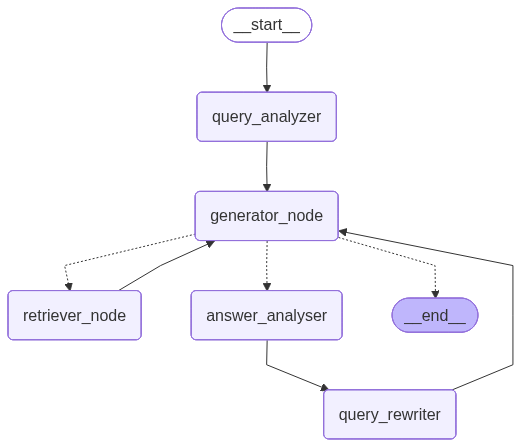

In [11]:
agent